In [10]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import local_binary_pattern, graycomatrix, graycoprops
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import warnings
warnings.filterwarnings("ignore")

BASE_DIR   = "chest_xray"
TRAIN_DIR  = os.path.join(BASE_DIR, "train")
TEST_DIR   = os.path.join(BASE_DIR, "test")
VAL_DIR    = os.path.join(BASE_DIR, "val")

IMG_SIZE = (224, 224)

print("Libraries imported correctly.")

Libraries imported correctly.


In [ ]:
VALID_EXTENSIONS = (".jpeg")

def extract_features(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    img = cv2.resize(img, IMG_SIZE)
    
    # LBP
    radius = 3
    n_points = 8 * radius
    lbp = local_binary_pattern(img, n_points, radius, method="uniform")
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, n_points + 3), density=True)
    
    # GLCM
    distances = [1, 3]
    angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]
    glcm = graycomatrix(img, distances=distances, angles=angles,
                        levels=256, symmetric=True, normed=True)
    
    contrast    = graycoprops(glcm, "contrast").ravel()
    correlation  = graycoprops(glcm, "correlation").ravel()
    energy      = graycoprops(glcm, "energy").ravel()
    homogeneity = graycoprops(glcm, "homogeneity").ravel()
    
    features = np.concatenate([lbp_hist, contrast, correlation, energy, homogeneity])
    return features

def load_dataset(path):
    X, y = [], []
    for c in ["NORMAL", "PNEUMONIA"]:
        folder = os.path.join(path, c)
        files = [f for f in os.listdir(folder) if f.lower().endswith(VALID_EXTENSIONS)]
        print(f"Processing {c}: {len(files)} images...")
        for file in files:
            features = extract_features(os.path.join(folder, file))
            if features is not None:
                X.append(features)
                y.append(c)
    return np.array(X), np.array(y)

folder = os.path.join(TRAIN_DIR, "NORMAL")
first_file = [f for f in os.listdir(folder) if f.lower().endswith(VALID_EXTENSIONS)][0]
test = extract_features(os.path.join(folder, first_file))
print(f"Feature vector shape: {test.shape}")

Feature vector shape: (58,)


In [12]:
print("Loading train...")
X_train, y_train = load_dataset(TRAIN_DIR)

print("\nLoading test...")
X_test, y_test = load_dataset(TEST_DIR)

print("\nLoading val...")
X_val, y_val = load_dataset(VAL_DIR)

# Join train + val for final training
X_train = np.concatenate([X_train, X_val])
y_train = np.concatenate([y_train, y_val])

print(f"\nFinal Training Set: {X_train.shape}")
print(f"Final Test Set:        {X_test.shape}")

Loading train...
Processing NORMAL: 1341 images...
Processing PNEUMONIA: 3875 images...

Loading test...
Processing NORMAL: 234 images...
Processing PNEUMONIA: 390 images...

Loading val...
Processing NORMAL: 8 images...
Processing PNEUMONIA: 8 images...

Final Training Set: (5232, 58)
Final Test Set:        (624, 58)


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("Training Random Forest...")
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# Eval
y_pred_rf = rf.predict(X_test)

print("\n--- Random Forest ---")
print(classification_report(y_test, y_pred_rf))

Training Random Forest...

--- Random Forest ---
              precision    recall  f1-score   support

      NORMAL       0.95      0.38      0.55       234
   PNEUMONIA       0.73      0.99      0.84       390

    accuracy                           0.76       624
   macro avg       0.84      0.69      0.69       624
weighted avg       0.81      0.76      0.73       624



In [14]:
print("Training XGBoost...")

# Turn labels to numbers (XGBoost requires 0 and 1)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

ratio = (y_train == "NORMAL").sum() / (y_train == "PNEUMONIA").sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    scale_pos_weight=1/ratio,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_model.fit(X_train, y_train_enc)

y_pred_xgb = le.inverse_transform(xgb_model.predict(X_test))

print("\n--- XGBoost ---")
print(classification_report(y_test, y_pred_xgb))

Training XGBoost...

--- XGBoost ---
              precision    recall  f1-score   support

      NORMAL       0.95      0.36      0.52       234
   PNEUMONIA       0.72      0.99      0.83       390

    accuracy                           0.75       624
   macro avg       0.84      0.67      0.68       624
weighted avg       0.81      0.75      0.72       624



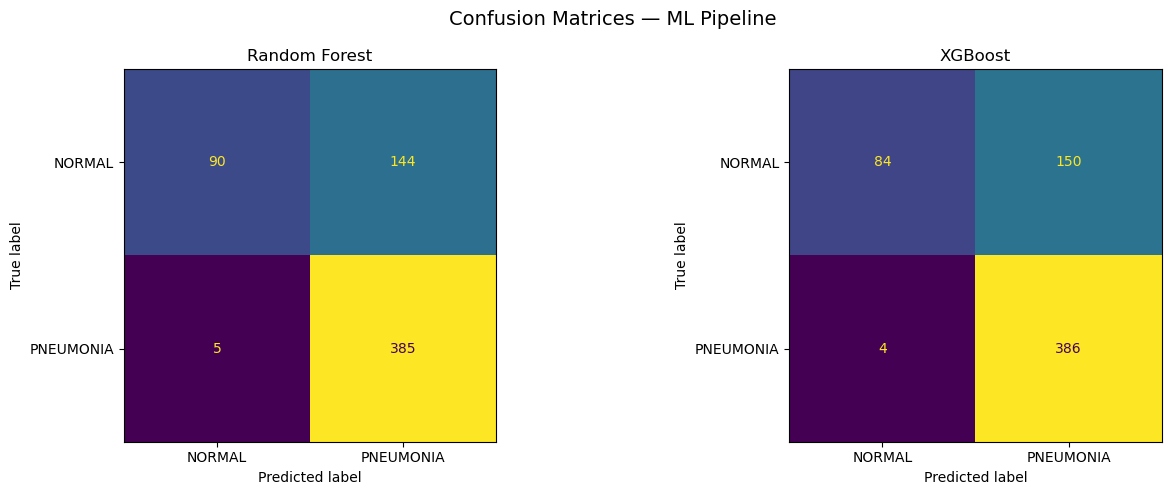

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=["NORMAL", "PNEUMONIA"])
disp_rf = ConfusionMatrixDisplay(cm_rf, display_labels=["NORMAL", "PNEUMONIA"])
disp_rf.plot(ax=axes[0], colorbar=False)
axes[0].set_title("Random Forest")

# XGBoost Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb, labels=["NORMAL", "PNEUMONIA"])
disp_xgb = ConfusionMatrixDisplay(cm_xgb, display_labels=["NORMAL", "PNEUMONIA"])
disp_xgb.plot(ax=axes[1], colorbar=False)
axes[1].set_title("XGBoost")

plt.suptitle("Confusion Matrices — ML Pipeline", fontsize=14)
plt.tight_layout()
plt.show()

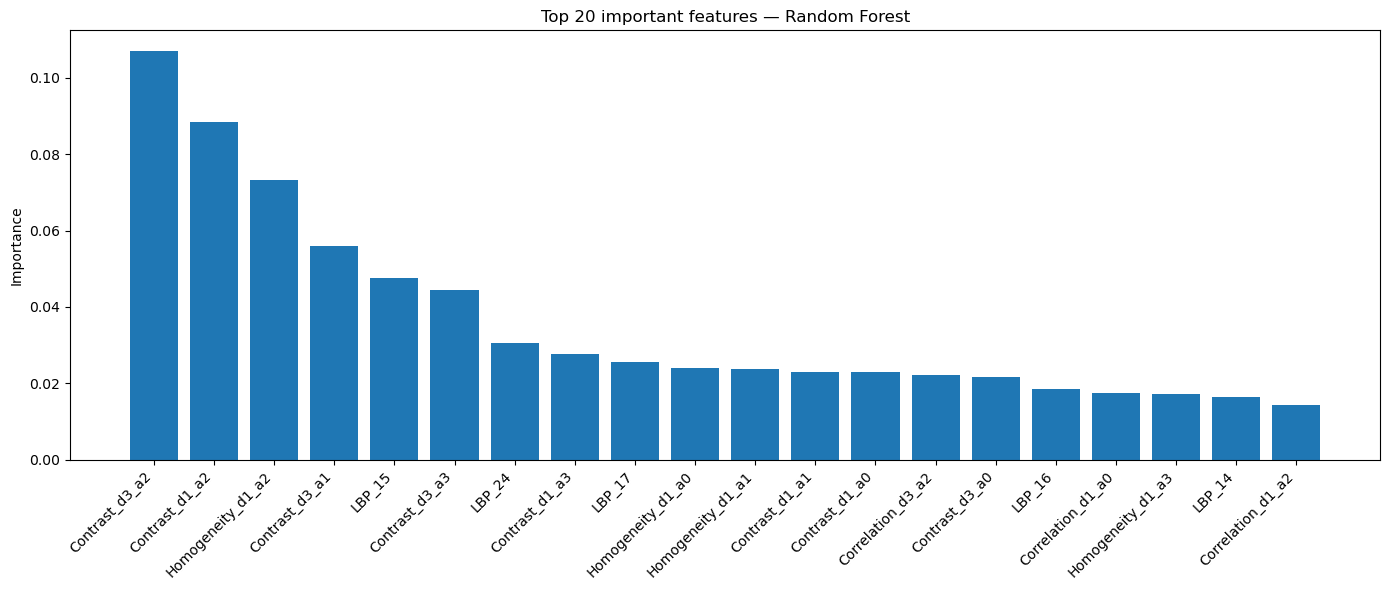


Top 10 features:
  Contrast_d3_a2: 0.1071
  Contrast_d1_a2: 0.0885
  Homogeneity_d1_a2: 0.0733
  Contrast_d3_a1: 0.0560
  LBP_15: 0.0476
  Contrast_d3_a3: 0.0445
  LBP_24: 0.0306
  Contrast_d1_a3: 0.0275
  LBP_17: 0.0255
  Homogeneity_d1_a0: 0.0240


In [16]:
n_points = 24
feature_names = (
    [f"LBP_{i}" for i in range(n_points + 2)] +
    [f"Contrast_d{d}_a{i}"    for d in [1,3] for i in range(4)] +
    [f"Correlation_d{d}_a{i}"  for d in [1,3] for i in range(4)] +
    [f"Energy_d{d}_a{i}"      for d in [1,3] for i in range(4)] +
    [f"Homogeneity_d{d}_a{i}" for d in [1,3] for i in range(4)]
)

# Feature importance of Random Forest
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1][:20]  # top 20

plt.figure(figsize=(14, 6))
plt.bar(range(20), importances[indices])
plt.xticks(range(20), [feature_names[i] for i in indices], rotation=45, ha="right")
plt.title("Top 20 important features — Random Forest")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
for i in range(10):
    print(f"  {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")